## interpretacion

### By:
Maria Camila Sepulveda Torres

### Date:
2026-08-21



## 📚 Import  libraries

In [24]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import load
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve, train_test_split

## 💾 Load data

In [2]:
DATA_MODEL = Path.cwd().resolve().parents[1] / "models"

admission_model = load(DATA_MODEL / "ridge_optimized_pipeline.joblib")

print("Pandas version: ", pd.__version__)

Pandas version:  3.0.5


# interpretacion

##Feature importance

In [3]:
features = admission_model["preprocessor"].get_feature_names_out()
coefficients = admission_model["model"].coef_

df_features = pd.DataFrame(
    {
        "Features": features,
        "Coefficients": coefficients,
        "Absolute Importance": np.abs(coefficients),
    }
)

df_features = df_features.sort_values(
    by="Absolute Importance",
    ascending=False,
)

df_features

,Features,Coefficients,Absolute Importance
5,numeric__CGPA,0.063608,0.063608
1,numeric__TOEFL Score,0.024009,0.024009
0,numeric__GRE Score,0.023555,0.023555
6,categoric ordinal__Research,0.021768,0.021768
4,numeric__LOR,0.017425,0.017425
2,numeric__University Rating,0.002010,0.002010
3,numeric__SOP,0.001535,0.001535


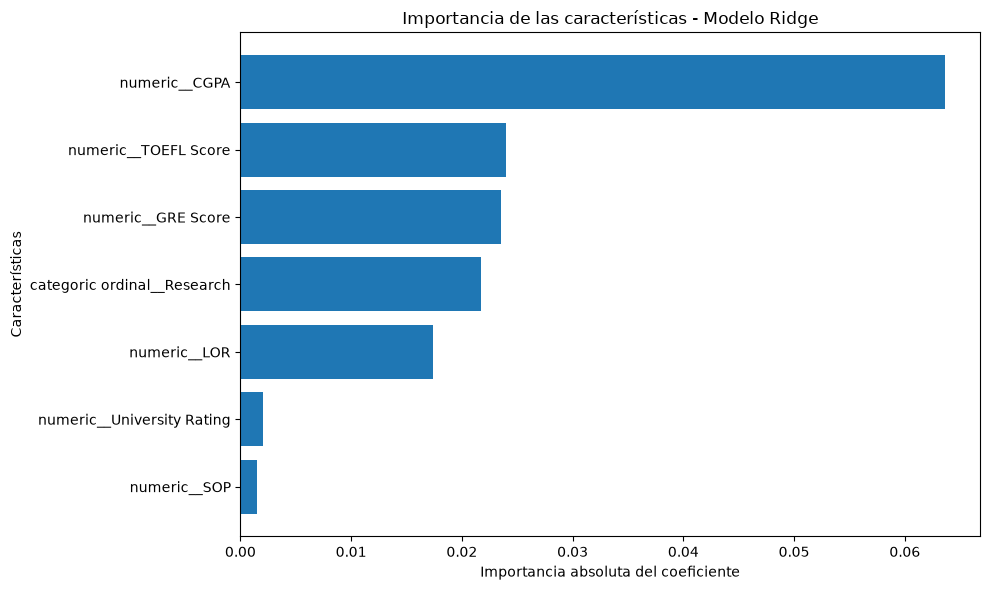

In [4]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_features["Features"],
    df_features["Absolute Importance"],
)

plt.xlabel("Importancia absoluta del coeficiente")
plt.ylabel("Características")
plt.title("Importancia de las características - Modelo Ridge")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretación de la importancia de las características

La característica con mayor influencia en el modelo Ridge es CGPA, con un coeficiente de 0.0636, lo que indica que el desempeño académico acumulado tiene el mayor peso en la predicción de la probabilidad de admisión.

En un segundo grupo se encuentran TOEFL Score (0.0240), GRE Score (0.0236) y Research (0.0218), que también aportan información relevante a la predicción. Por su parte, LOR (0.0174) presenta una contribución menor.

Las características University Rating (0.0020) y SOP (0.0015) presentan los coeficientes de menor magnitud, por lo que su influencia en las predicciones del modelo es considerablemente menor.

Todos los coeficientes obtenidos son positivos, indicando que, manteniendo las demás características constantes, incrementos en estas variables se asocian con incrementos en la predicción de la probabilidad de admisión.

Debido a que el modelo Ridge utiliza regularización L2, los coeficientes son penalizados para reducir su magnitud y limitar el sobreajuste. Por esta razón, esta interpretación debe complementarse con técnicas como la importancia por permutación.

## Feature permutation

In [6]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

admission_df = pd.read_parquet(DATA_DIR / "02_intermediate" / "admission_type_fixed.parquet")

admission_df = admission_df.drop_duplicates()

admission_df.info()

<class 'pandas.DataFrame'>
Index: 471 entries, 0 to 581
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          460 non-null    Int16  
 1   TOEFL Score        452 non-null    Int16  
 2   University Rating  465 non-null    float64
 3   SOP                455 non-null    float64
 4   LOR                463 non-null    float64
 5   CGPA               469 non-null    float64
 6   Research           442 non-null    boolean
 7   Chance of Admit    471 non-null    float64
dtypes: Int16(2), boolean(1), float64(5)
memory usage: 25.8 KB


In [7]:
X = admission_df.drop(columns=["Chance of Admit"])
y = admission_df["Chance of Admit"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (376, 7)
Test: (95, 7)


In [8]:
imps = permutation_importance(
    admission_model,
    x_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

df_permutation = pd.DataFrame(
    {
        "Features": x_test.columns,
        "Importances Mean": imps.importances_mean,
        "Importances STD": imps.importances_std,
    }
)

df_permutation = df_permutation.sort_values(
    by="Importances Mean",
    ascending=False,
)

df_permutation

,Features,Importances Mean,Importances STD
5,CGPA,0.045614,0.007093
0,GRE Score,0.007381,0.002061
1,TOEFL Score,0.004564,0.002259
4,LOR,0.004172,0.001830
6,Research,0.001281,0.001085
2,University Rating,0.000175,0.000158
3,SOP,-0.000049,0.000117


/tmp/ipykernel_13882/3457681930.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


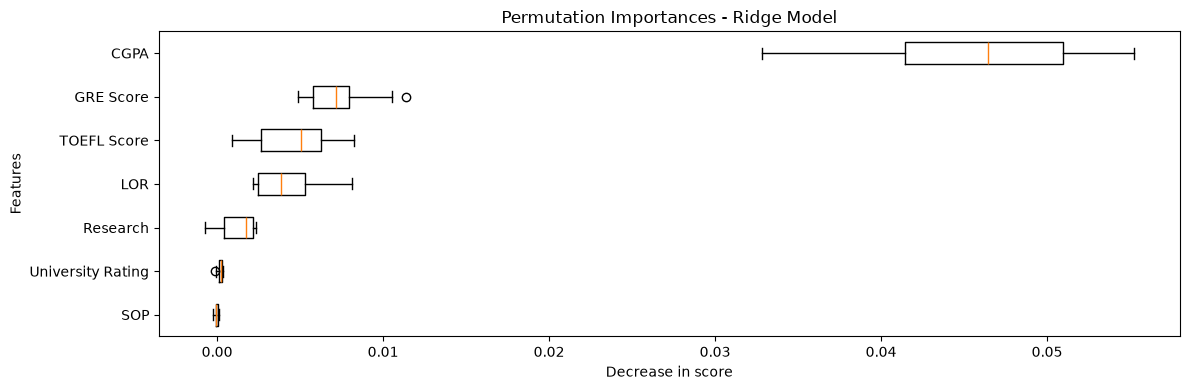

In [9]:
sorted_idx = imps.importances_mean.argsort()

plt.figure(figsize=(12, 4))
plt.boxplot(
    imps.importances[sorted_idx].T,
    vert=False,
    tick_labels=x_test.columns[sorted_idx],
)

plt.xlabel("Decrease in score")
plt.ylabel("Features")
plt.title("Permutation Importances - Ridge Model")
plt.tight_layout()
plt.show()

### Interpretación de la importancia por permutación

Los resultados de la importancia por permutación confirman que CGPA es la característica con mayor influencia sobre el desempeño predictivo del modelo Ridge. Su importancia media (0.0456) es considerablemente superior a la observada para las demás variables, lo que indica que alterar sus valores produce la mayor disminución en el desempeño del modelo.

En un segundo nivel se encuentran GRE Score (0.0074), TOEFL Score (0.0046) y LOR (0.0042). Estas características contribuyen al desempeño predictivo, aunque su efecto es considerablemente menor que el de CGPA. Research (0.0013) presenta una contribución más reducida.

Por su parte, University Rating (0.0002) y SOP (-0.00005) muestran una importancia cercana a cero. En particular, el valor ligeramente negativo de SOP no implica necesariamente un efecto perjudicial sobre el modelo, ya que su magnitud es mínima y se encuentra dentro de la variabilidad observada entre las permutaciones. Esto sugiere que SOP aporta poca información predictiva adicional en el conjunto de prueba.

En conjunto, la importancia por permutación respalda la interpretación obtenida mediante los coeficientes del modelo: el desempeño académico, particularmente CGPA, constituye el principal factor asociado con las predicciones de admisión realizadas por el modelo.

## Learning Curve

In [12]:
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    admission_model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    return_times=True,
)

train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)

test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

fit_times_mean = np.mean(fit_times, axis=1)
fit_times_std = np.std(fit_times, axis=1)

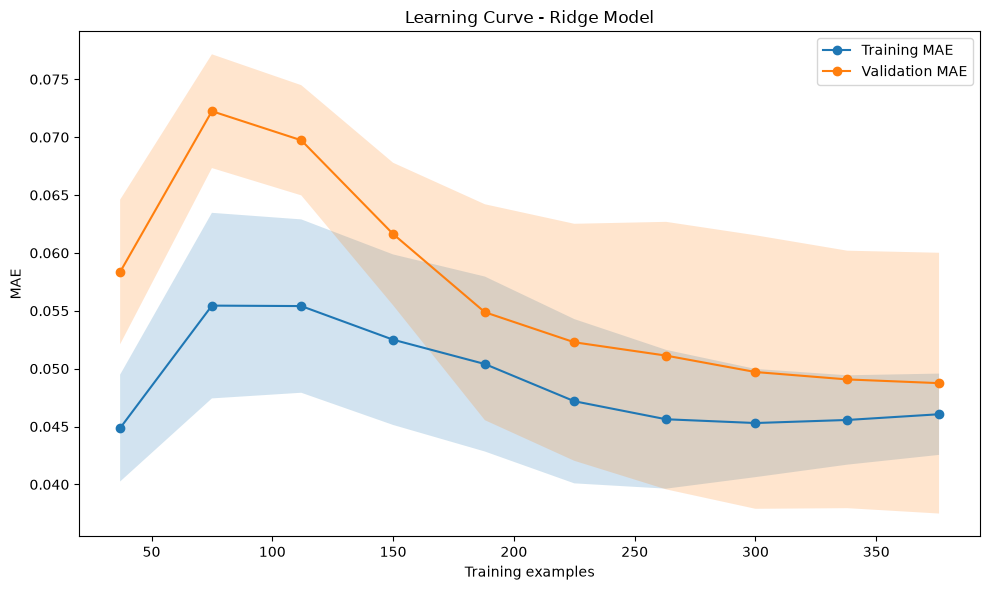

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_scores_mean,
    marker="o",
    label="Training MAE",
)

plt.plot(
    train_sizes,
    test_scores_mean,
    marker="o",
    label="Validation MAE",
)

plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2,
)

plt.fill_between(
    train_sizes,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2,
)

plt.xlabel("Training examples")
plt.ylabel("MAE")
plt.title("Learning Curve - Ridge Model")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de la curva de aprendizaje

La curva de aprendizaje muestra que, a medida que aumenta el número de ejemplos utilizados para el entrenamiento, el error de validación disminuye progresivamente y se aproxima al error de entrenamiento.

Con el conjunto de entrenamiento completo, el MAE de entrenamiento se encuentra alrededor de 0.046, mientras que el MAE de validación se aproxima a 0.049. La pequeña diferencia entre ambas curvas indica que el modelo presenta una capacidad de generalización adecuada y no evidencia un sobreajuste significativo.

En los tamaños de muestra más pequeños se observa una mayor variabilidad en los resultados. Sin embargo, esta variabilidad disminuye a medida que se incorporan más observaciones, produciendo un comportamiento más estable.

Hacia el final, ambas curvas comienzan a estabilizarse y mantienen una brecha reducida. Aunque la incorporación de más datos podría generar mejoras adicionales en la capacidad de generalización, la tendencia observada sugiere que estas mejoras probablemente serían graduales.

## escalabilidad

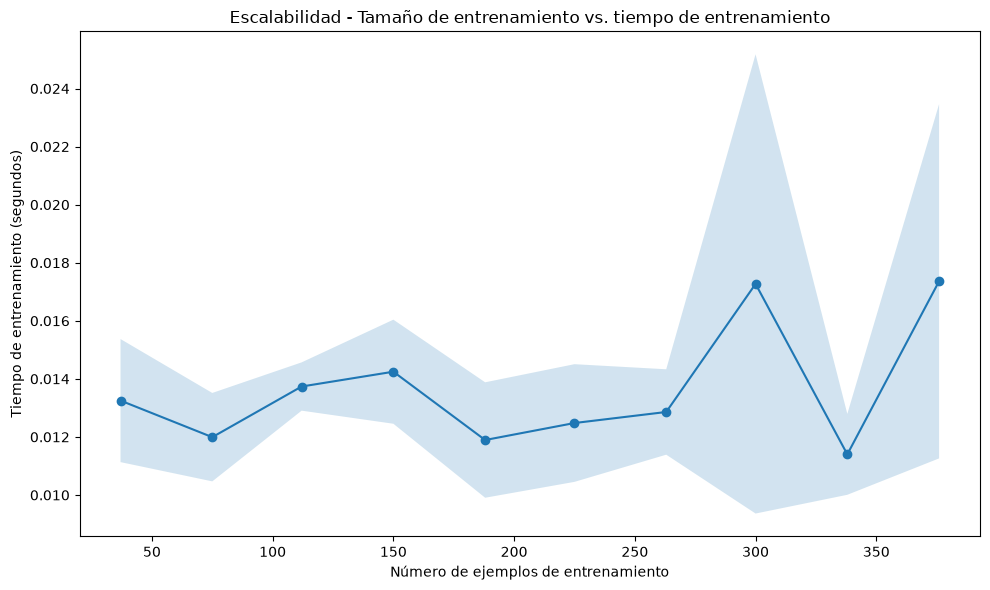

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    fit_times_mean,
    marker="o",
)

plt.fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.2,
)

plt.xlabel("Número de ejemplos de entrenamiento")
plt.ylabel("Tiempo de entrenamiento (segundos)")
plt.title("Escalabilidad - Tamaño de entrenamiento vs. tiempo de entrenamiento")
plt.tight_layout()
plt.show()

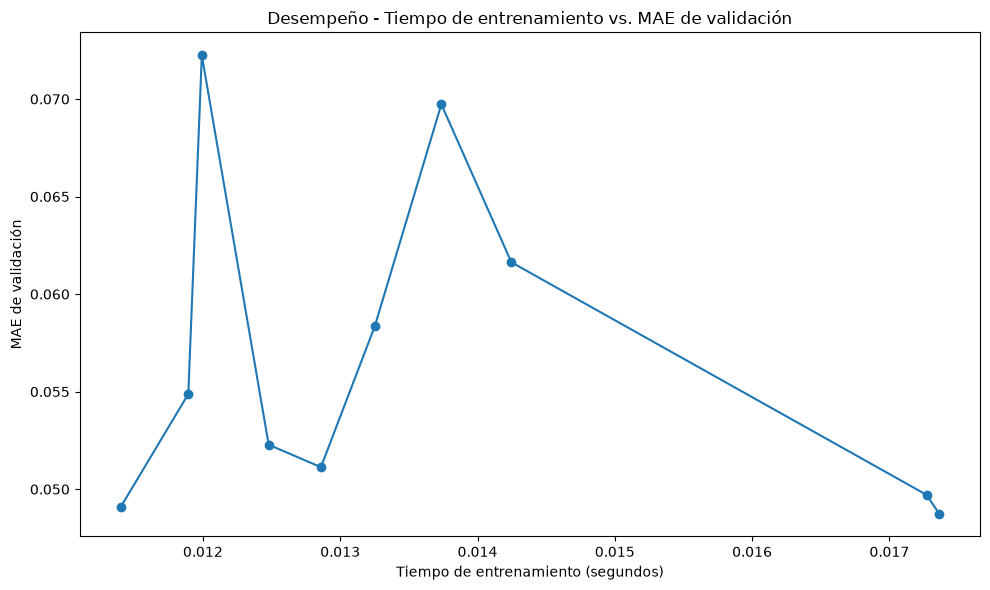

In [18]:
sorted_time_idx = np.argsort(fit_times_mean)

plt.figure(figsize=(10, 6))

plt.plot(
    fit_times_mean[sorted_time_idx],
    test_scores_mean[sorted_time_idx],
    marker="o",
)

plt.xlabel("Tiempo de entrenamiento (segundos)")
plt.ylabel("MAE de validación")
plt.title("Desempeño - Tiempo de entrenamiento vs. MAE de validación")
plt.tight_layout()
plt.show()

### Interpretación de la escalabilidad

Los tiempos de entrenamiento del modelo Ridge son bajos para el conjunto de datos analizado, manteniéndose aproximadamente entre 0.012 y 0.017 segundos. Aunque se presentan fluctuaciones entre los diferentes tamaños de entrenamiento, no se observa un incremento pronunciado del tiempo de ajuste a medida que aumenta el número de observaciones.

La relación entre el tiempo de entrenamiento y el MAE de validación muestra que la mejora del desempeño está asociada principalmente con el aumento de información disponible para el entrenamiento y no con incrementos sustanciales en el costo computacional. Con los tamaños de muestra más grandes, el MAE de validación se estabiliza alrededor de 0.049.

Los resultados indican que, para el volumen de datos utilizado en este proyecto, el modelo Ridge presenta un costo computacional reducido. Sin embargo, debido al tamaño limitado del conjunto de datos, estas pruebas no permiten concluir cómo se comportaría el tiempo de entrenamiento ante incrementos considerablemente mayores en el volumen de información.

## Análisis de errores del modelo

In [19]:
y_pred = admission_model.predict(x_test)

df_errors = x_test.copy()
df_errors["Valor real"] = y_test
df_errors["Predicción"] = y_pred
df_errors["Error"] = y_test - y_pred
df_errors["Error absoluto"] = np.abs(y_test - y_pred)

df_errors = df_errors.sort_values(
    by="Error absoluto",
    ascending=False,
)

df_errors.head(10)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Valor real,Predicción,Error,Error absoluto
9,323,108,3.0,3.5,3.0,8.60,False,0.45,0.718942,-0.268942,0.268942
419,299,<NA>,3.0,5.0,NaN,7.66,False,0.38,0.575788,-0.195788,0.195788
423,304,<NA>,4.0,NaN,2.5,7.84,False,0.42,0.585625,-0.165625,0.165625
42,313,107,2.0,2.5,2.0,8.50,True,0.53,0.682533,-0.152533,0.152533
63,315,107,2.0,4.0,3.0,8.50,True,0.56,0.708386,-0.148386,0.148386
93,301,97,2.0,3.0,3.0,7.88,True,0.44,0.571483,-0.131483,0.131483
519,331,115,5.0,NaN,3.5,NaN,True,0.93,0.800286,0.129714,0.129714
386,302,101,2.0,2.5,3.5,7.96,False,0.46,0.585140,-0.125140,0.125140
39,307,108,2.0,4.0,3.5,7.70,False,0.48,0.597394,-0.117394,0.117394
18,318,110,3.0,4.0,3.0,8.80,False,0.63,0.738774,-0.108774,0.108774


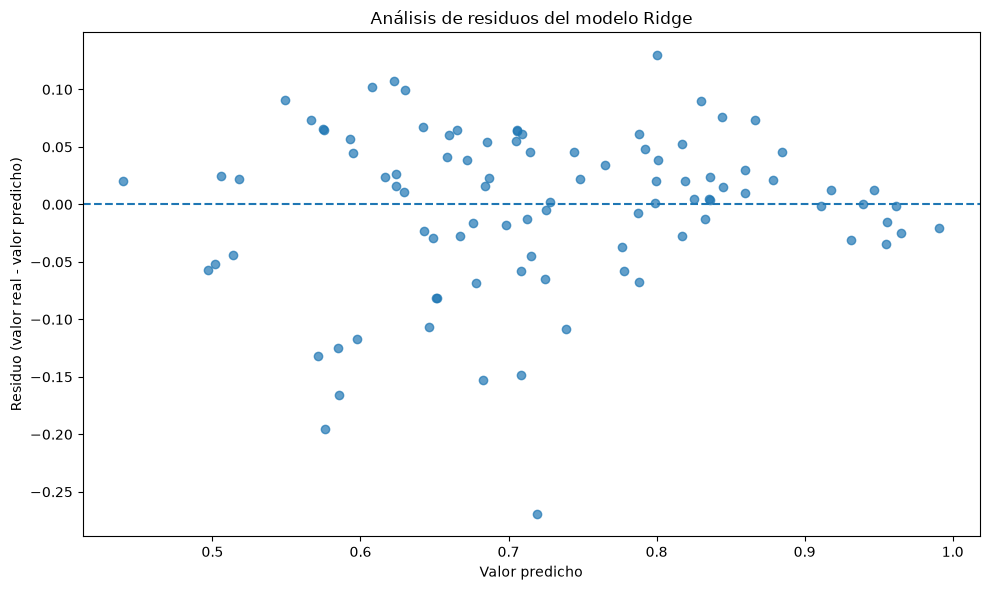

In [20]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    y_test - y_pred,
    alpha=0.7,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Valor predicho")
plt.ylabel("Residuo (valor real - valor predicho)")
plt.title("Análisis de residuos del modelo Ridge")
plt.tight_layout()
plt.show()

### Interpretación de los errores

El análisis de residuos muestra que la mayoría de las predicciones se concentran alrededor de un error igual a cero; sin embargo, existen observaciones con errores considerablemente mayores.

Entre las diez predicciones con mayor error absoluto predominan los residuos negativos, lo que indica que, en estos casos extremos, el modelo tiende principalmente a sobreestimar la probabilidad de admisión. El mayor error observado corresponde a un estudiante con una probabilidad real de admisión de 0.45, para quien el modelo predijo aproximadamente 0.719, generando un error absoluto cercano a 0.269.

También se identifican errores importantes en registros que contienen valores faltantes en variables como **TOEFL Score, LOR, SOP y CGPA**. Aunque el pipeline permite procesar estos registros mediante imputación, la presencia de datos faltantes podría reducir la información disponible para realizar algunas predicciones. No obstante, con este análisis no es posible afirmar que los valores faltantes sean por sí solos la causa de los errores.


In [23]:
overestimation = (df_errors["Error"] < 0).sum()
underestimation = (df_errors["Error"] > 0).sum()

print("Sobreestimaciones:", overestimation)
print("Subestimaciones:", underestimation)
print("Total de predicciones evaluadas:", len(df_errors))

Sobreestimaciones: 39
Subestimaciones: 56
Total de predicciones evaluadas: 95


## ¿A qué se deben los errores?

Los errores del modelo pueden estar relacionados con los siguientes aspectos:

- Valores atípicos: se identificaron algunas observaciones con residuos considerablemente mayores al resto, por lo que se recomienda analizar estos casos individualmente.

- Distribución de la variable objetivo: al tratarse de un problema de regresión no existe desbalance de clases. Sin embargo, algunos rangos de `Chance of Admit` podrían estar menos representados y generar mayores errores.

-Datos faltantes o errores de entrada:entre las predicciones con mayor error aparecen registros con valores faltantes. Aunque el pipeline realiza imputación, es necesario evaluar su efecto y validar que los datos se encuentren dentro de los rangos esperados.

-Codificación y preprocesamiento: no existe evidencia suficiente para afirmar que los encoders sean la causa de los errores, pero se pueden evaluar otras estrategias de transformación en una siguiente iteración.

- Limitaciones del modelo:Ridge modela principalmente relaciones lineales, por lo que puede tener dificultades para representar relaciones más complejas entre las características y la probabilidad de admisión.

## Pruebas y experimentos para la siguiente iteración

A partir de los resultados obtenidos, se proponen los siguientes experimentos:

1. Analizar los casos con mayores residuos, para identificar valores atípicos y características comunes entre las predicciones con mayor error.
2. Evaluar el efecto de los datos faltantes, comparando diferentes estrategias de imputación.
3. Validar los rangos de las variables de entrada, con el fin de identificar posibles valores inconsistentes o errores de ingreso.
4. Analizar el error por rangos de `Chance of Admit`, para determinar si el modelo presenta mayor dificultad en probabilidades bajas, medias o altas.
5. Evaluar alternativas de preprocesamiento y codificación para las variables ordinales.
6. Comparar Ridge con modelos no lineales, especialmente en los casos donde el modelo actual presenta mayores errores.
7. Evaluar la incorporación de nuevos datos, considerando que la curva de aprendizaje muestra mejoras graduales al aumentar el número de observaciones.